## **Rational Nonlinearity Learned by SREINet**


## **I. Setup and Preprocessing**

In [15]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


#### Create dataset

Guessed multiplicative_order: 2


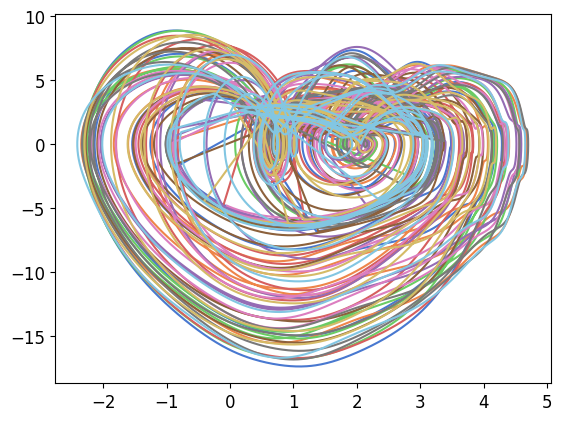

Training input shape: (30000, 10)
Training output shape: (30000, 10)


In [16]:
# Specify the model type
MY_MODEL = 'lorenz_96_sin' 
MY_DATA_TYPE = 'float32'

# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

# Generate data based on the specified model
dim = 10
num_traj = 6
data_initial_conditions = DG.DataGenerator.generate_initial_conditions(dim, num_traj, seed=42) #np.random.normal(1, 2, LORENZ96_DIM

data_T =  5.0       # Length of the data (T)
data_dt = 0.001       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions, T=data_T, dt=data_dt, derivative_mode="exact")


t_arr, x_train, dx_train, guessed_multiplicative_order = myDG.generate_dataset_by_model_name(MY_MODEL, method='RK45')

print("Guessed multiplicative_order:", guessed_multiplicative_order)

#plot x_train and dx_train
import matplotlib.pyplot as plt
plt.plot(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**


In [17]:
# Set mini-batch size
MINI_BATCH_SIZE = 64
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [18]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guessed_multiplicative_order


n_second_order_terms = dim * (dim + 1) // 2  
lifting_output_dim = dim + n_second_order_terms  

layer_neuron_nums_per_act_fn = [lifting_output_dim] * layer_depth

## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [19]:
class LiftingLayer(tf.keras.layers.Layer):
    """
    Simple transformation layer that generates input to SREINet. This layer allows for incorporating 
    custom transformation functions such as 1/(ax+b) and xi*xj.
    """
    
    def __init__(self, **kwargs):
        """
        Args:
            input_dim: Input dimension (number of input features)
            delta: Small constant to prevent division by zero
            seed: Random seed
        """
        super(LiftingLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.input_dim = input_shape[-1]
        
        indices_pairs = []
        for i in range(self.input_dim):
            for j in range(i, self.input_dim):
               indices_pairs.append([i, j])
        
        self.indices_pairs = tf.constant(indices_pairs, dtype=tf.int32)


    def call(self, inputs):
        """
        Apply transformations: [original_coords, custom_transforms]
        """
        input_dim = inputs.shape[-1]
        tensor_prod = tf.einsum('bi,bj->bij', inputs, inputs) 

        B = tf.shape(tensor_prod)[0]  

        indices = tf.tile(self.indices_pairs[None, :, :], [B, 1, 1])  # (B, 15, 2)

        second_order = tf.gather_nd(tensor_prod, indices, batch_dims=1)

        sine_second_order = tf.sin(second_order) #hard code. To be modify in future.
    
        return tf.concat([inputs, sine_second_order], axis=-1)
    

In [20]:

def create_extended_sreinet_model(dim, layer_neuron_nums_per_act_fn, activation_functions=[lambda x:x], 
                        weight_std=0.001, delta=1e-5, seed=42, data_type='float32'):
    """
    Create and initialize a SREINet model.
    
    Args:
        dim (int): Input dimension (number of input variables)
        layer_neuron_nums_per_act_fn (list): Number of neurons per activation function in each hidden layer
        activation_functions (list, optional): List of activation functions. Defaults to [lambda x:x]
        weight_std (float, optional): Standard deviation for weight initialization. Defaults to 0.001
        delta: small constant to avoid division by zero
        seed (int, optional): Random seed for reproducible initialization. Defaults to 42
        data_type (str, optional): Data type for the model. Defaults to 'float32'
    
    Returns:
        tf.keras.Model: Configured SREINet model
    """
    
    # Create input layer
    inputs = tf.keras.layers.Input(shape=(dim,), dtype=data_type)
    # Apply flexible transformation layer (includes original coordinates + transformations)
    lifting_layer = LiftingLayer(
        name='lifting_layer'
    ) #DO NOT CHANGE THIS NAME
    
    # Get transformed features (includes original coordinates automatically)
    transformed_inputs = lifting_layer(inputs)


    # Calculate output dimension for SREINet layers
    #need to revise, confusing
    
    # Create SREINet model
    sreinet = SREINet(layer_neuron_nums_per_act_fn,
                      activations=activation_functions,
                      weight_initializer=tf.initializers.random_normal(stddev=0.001, seed=seed),
                      data_type=data_type,
                      name='SREINet') #DO NOT CHANGE THIS NAME
    
    # Apply the SREINet to transformed inputs
    output = sreinet(transformed_inputs)
    
    # Create the final model
    model = tf.keras.Model(inputs=inputs, outputs=output)
    
    return model

model = create_extended_sreinet_model(dim, layer_neuron_nums_per_act_fn)


def reinitialize_model_weights(model):
    """
    Reinitialize weights of the SREINet model.
    
    Args:
        model (tf.keras.Model): The SREINet model to reinitialize
    """
    #need to update here

    if hasattr(model.layers[1], 'reinitialize_weights'):
        tf.random.set_seed(np.random.randint(10000))
        model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")

In [21]:
model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 10)]              0         
                                                                 
 lifting_layer (LiftingLaye  (None, 65)                0         
 r)                                                              
                                                                 
 SREINet (SREINet)           (None, 1)                 4422      
                                                                 
Total params: 4422 (17.27 KB)
Trainable params: 4356 (17.02 KB)
Non-trainable params: 66 (264.00 Byte)
_________________________________________________________________


### **2.2 Loss Function**

In [22]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [23]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Training with Pruning**

In [24]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Pruning Profile**

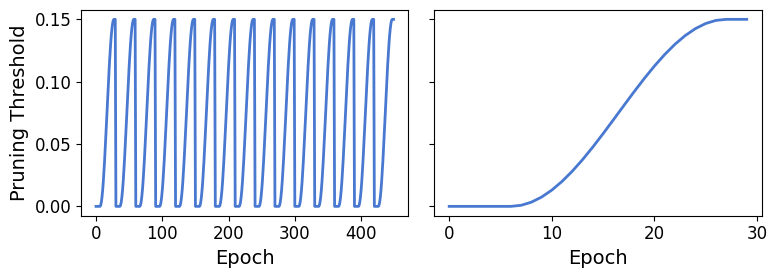

In [25]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.15 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 15
PRUNING_EPOCHS_PER_PERIOD = 30
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS


import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    show_plot=True)




### Training

In [26]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.02

training_histories = []
weights_list = []
loss_list = []

In [27]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0,training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 10
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 5.660e-01,  Validation Loss: 6.802e-02,  Epoch Time: 0.51s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 4.524e-02,  Validation Loss: 3.126e-02,  Epoch Time: 0.31s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 2.512e-02,  Validation Loss: 2.077e-02,  Epoch Time: 0.31s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 2.417e-02,  Validation Loss: 1.372e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 2.437e-02,  Validation Loss: 2.657e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 2.192e-02,  Validation Loss: 2.180e-02,  Epoch Time: 0.34s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.442e-02,  Validation Loss: 2.165e-02,  Epoch Time: 0.33s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 1.726e-02,  Validation Loss: 9.884e-03,  Epoc

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [28]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    N = dim #Temporary setup
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)] + [f'sin(x{i}*x{j})' for i in range(1, N+1) for j in range(i, N+1)]

#### `coefficient_reconstruction`

In [29]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [30]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 2.999993086 - 0.9999979138*x1 + 0.5000001192*sin(x1*x2) + 0.9999997914*x10*x2 - 0.9999994338*x10*x9
(x2)' = 3.000005245 - 1.000001609*x2 + 0.500000298*sin(x2*x3) + 1.000000179*x1*x3 - 1.000000477*x1*x10
(x3)' = 2.999998331 - 0.999999702*x3 + 0.5000001788*sin(x3*x4) - 0.9999998212*x1*x2 + 1.000000119*x2*x4
(x4)' = 2.999999285 - 1.000000119*x4 + 0.5000002384*sin(x4*x5) - 0.9999999404*x2*x3 + 1.000000179*x3*x5
(x5)' = 3.000008583 - 1.00000298*x5 + 0.4999999404*sin(x5*x6) - 1.000000715*x3*x4 + 1.000000477*x4*x6
(x6)' = 3 - 1.000000238*x6 + 0.5000000298*sin(x6*x7) - x4*x5 + 1.000000119*x5*x7
(x7)' = 2.999993086 - 0.9999979138*x7 + 0.5000002384*sin(x7*x8) - 0.999999404*x5*x6 + 0.9999998212*x6*x8
(x8)' = 3.000002384 - 1.000000894*x8 + 0.5000001788*sin(x8*x9) - 1.000000179*x6*x7 + 1.000000119*x7*x9
(x9)' = 3.000000954 - 1.000000536*x9 + 0.5000001192*sin(x9*x10) - x7*x8 + 1.000000119*x10*x8
(x10)' = 2.999997854 - 0.9999994636*x10 + 0.5000000596*sin(x1*x10) + x1*x9 - 0.9999998212*x8*x9


### **Validation**

In [31]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);


### Comparing vector field

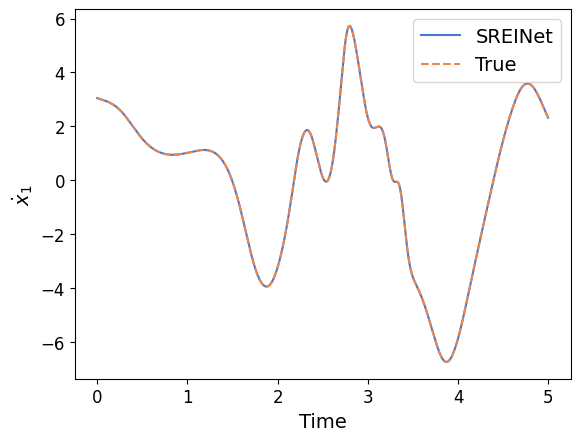

In [32]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [33]:
val_t_span = [0,10]
val_t_eval = np.arange(0,10,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

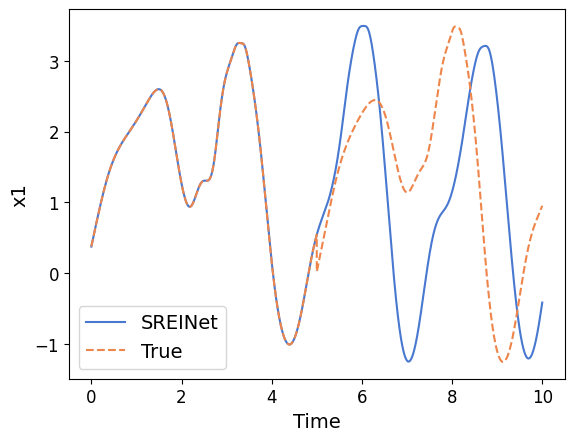

In [34]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

